# EVALUATION & VALIDATION

+ So sánh các mô hình
+ Đánh giá mô hình Random Forest sau khi sử dụng GridSearch
+ Xử lí dữ liệu mất cân bằng
+ Tìm ngưỡng tối ưu (Threshold Tuning)

## 1. Khởi tạo và đọc dữ liệu

### 1.1. Tải thư viện

Đầu tiên cần nhập các thư viện xử lí dữ liệu, đánh giá mô hình cũng như xử lí các vấn đề đã đề cập trước đó.

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib

# Thư viện đánh giá, phân chia dữ liệu, chuẩn hóa
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
    precision_recall_curve, classification_report, accuracy_score,
    precision_score, recall_score, f1_score )    


# Các mô hình ML
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# Xử lý dữ liệu không cân bằng
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

### 1.2. Đọc dữ liệu

In [51]:
# Đọc dữ liệu
# 1. Dữ liệu đã Scale (Dùng cho Logistic Regression, SVM, KNN)
df_scaled = pd.read_csv('HR_Analytics_Selected_Scaled.csv')

# 2. Dữ liệu chưa Scale (Dùng cho Decision Tree / Random Forest để giữ nguyên ý nghĩa gốc của dữ liệu)
df_not_scaled = pd.read_csv('HR_Analytics_Selected_NotScaled.csv')

print("Kích thước của bộ dữ liệu Scaled :", df_scaled.shape)
print("Kích thước của bộ dữ liệu chưa Scaled:", df_not_scaled.shape)

Kích thước của bộ dữ liệu Scaled : (1470, 26)
Kích thước của bộ dữ liệu chưa Scaled: (1470, 26)


In [52]:
# Xác định biến mục tiêu và biến độc lập
target = 'Attrition'

# Dữ liệu Scaled
X_scaled = df_scaled.drop(target, axis=1)
y_scaled = df_scaled[target]

X_train_sc, X_test_sc, y_train_sc, y_test_sc = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42, stratify=y_scaled
)

# Dữ liệu Not Scaled (Cho Tree-based models)
X_not_scaled = df_not_scaled.drop(target, axis=1)
y_not_scaled = df_not_scaled[target]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_not_scaled, y_not_scaled, test_size=0.2, random_state=42, stratify=y_not_scaled
)

print(f"Train size: {X_train_sc.shape[0]}, Test size: {X_test_sc.shape[0]}")

Train size: 1176, Test size: 294


## 2. Đánh giá từng mô hình

Tiếp theo cần đánh giá lại các mô hình ở file Model.ipynb

**Đánh giá dựa trên tiêu chí:**
+ Accuracy and classification report
+ Confusion matrix
+ ROC-AUC Curve

### 2.1 Nhóm thuật toán dựa trên khoảng cách (Distance-based)


===== Logistic Regression =====
Accuracy: 0.7279
              precision    recall  f1-score   support

         0.0       0.94      0.72      0.82       247
         1.0       0.34      0.74      0.47        47

    accuracy                           0.73       294
   macro avg       0.64      0.73      0.64       294
weighted avg       0.84      0.73      0.76       294



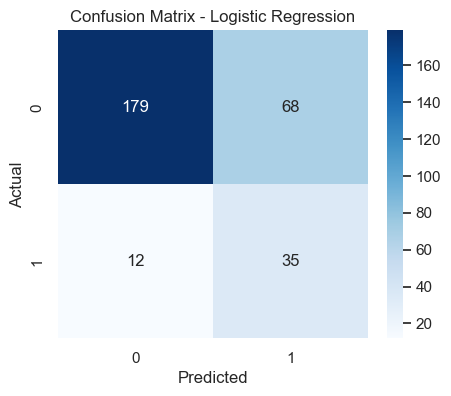

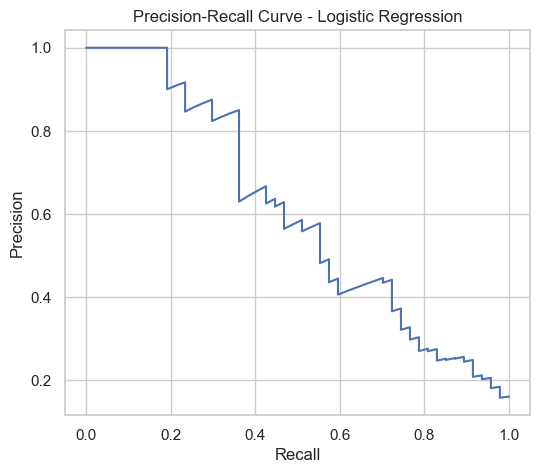


===== Support Vector Machine =====
Accuracy: 0.8095
              precision    recall  f1-score   support

         0.0       0.92      0.84      0.88       247
         1.0       0.43      0.64      0.52        47

    accuracy                           0.81       294
   macro avg       0.68      0.74      0.70       294
weighted avg       0.85      0.81      0.82       294



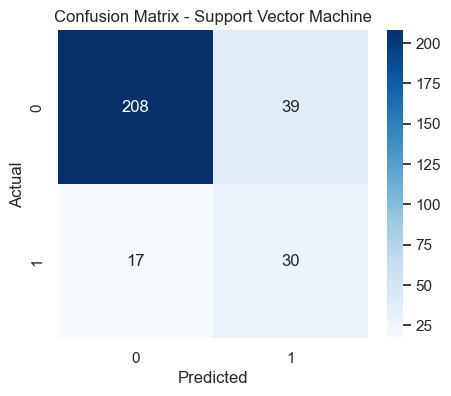

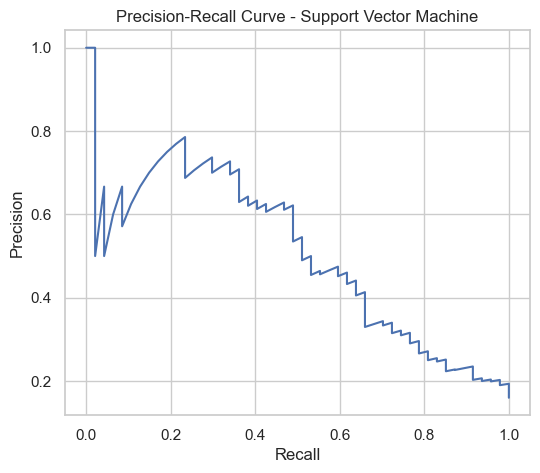


===== K-Nearest Neighbors =====
Accuracy: 0.8231
              precision    recall  f1-score   support

         0.0       0.85      0.96      0.90       247
         1.0       0.35      0.13      0.19        47

    accuracy                           0.82       294
   macro avg       0.60      0.54      0.54       294
weighted avg       0.77      0.82      0.79       294



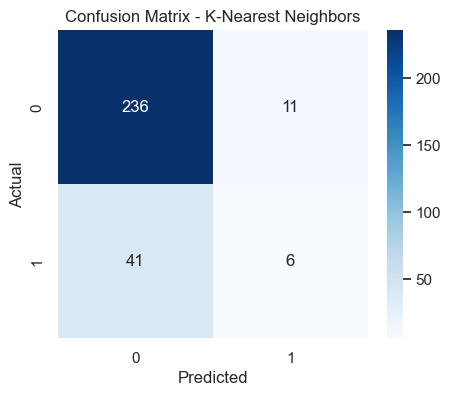

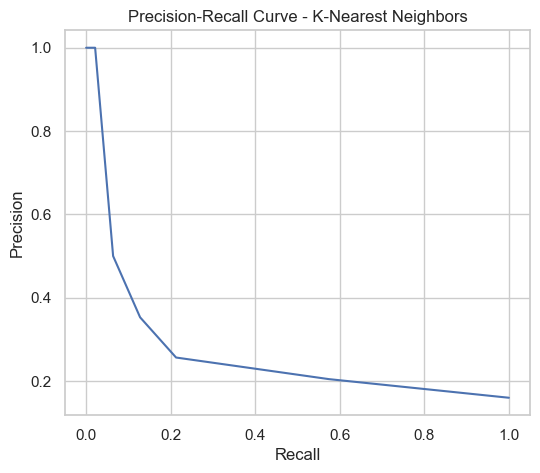

In [53]:
models_sc = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Support Vector Machine": SVC(probability=True, class_weight='balanced'),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

for name, model in models_sc.items():
    
    print(f"\n===== {name} =====")

    # Train
    model.fit(X_train_sc, y_train_sc)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    # Độ chính xác và báo cáo phân loại 
    acc = accuracy_score(y_test_sc, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test_sc, y_pred))

    # Ma trận nhầm lẫn
    cm = confusion_matrix(y_test_sc, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # PRECISION-RECALL CURVE
    precision, recall, _ = precision_recall_curve(y_test_sc, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision)
    plt.title(f"Precision-Recall Curve - {name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

**Nhận xét:**
+ **Logistic Regression:** Mô hình Logistic Regression đạt độ chính xác 72.8% nhưng không có giá trị vì dữ liệu lệch nặng. Recall phân biệt khá tốt tuy nhiên Precision chỉ 34% (trong 103 cảnh báo thì 68 là không chính xác) khiến số lượng báo động nhầm quá lớn. F1-score lớp thiểu số chỉ 0.47, cho thấy hiệu suất thực tế chưa đạt.

+ **Support Vector Machine:** So với Logistic Regression, SVM đánh đổi một ít Recall để lấy lại Precision cao hơn đáng kể, lượng False Negative (39) cũng giảm đáng kể. Precision đã đủ tin cậy, số cảnh báo nhầm giảm mạnh.

+ **K-Nearest Neighbors:** KNN bị nghiêng hẳn về lớp đa số (lớp 0 đạt Recall 0.96, Precision 0.85) do bản chất nhạy cảm với mất cân bằng dữ liệu và không có cơ chế xử lý class imbalance hiệu quả. Precision-Recall Curve gần như sụp thẳng đứng ngay từ Recall thấp, chứng tỏ mô hình hầu như không học được đặc trưng của lớp thiểu số.

### 2.2 Nhóm mô hình cây quyết định (Tree-based Models)


===== Decision Tree =====
Accuracy: 0.7279
              precision    recall  f1-score   support

         0.0       0.90      0.76      0.82       247
         1.0       0.31      0.55      0.39        47

    accuracy                           0.73       294
   macro avg       0.60      0.66      0.61       294
weighted avg       0.80      0.73      0.76       294



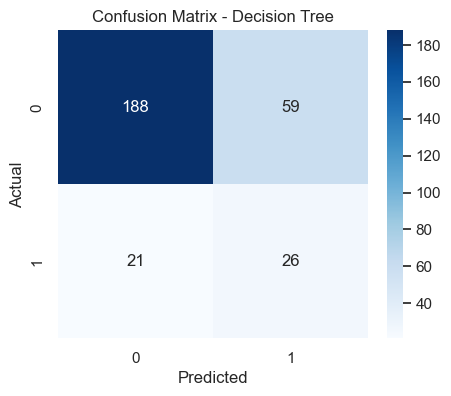

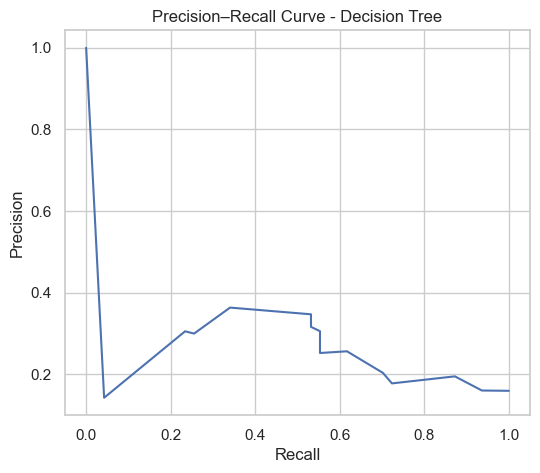


===== Random Forest =====
Accuracy: 0.8367
              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91       247
         1.0       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



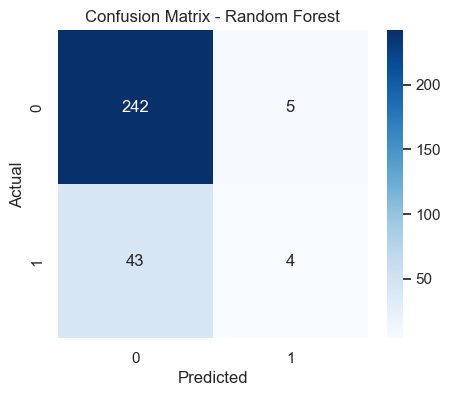

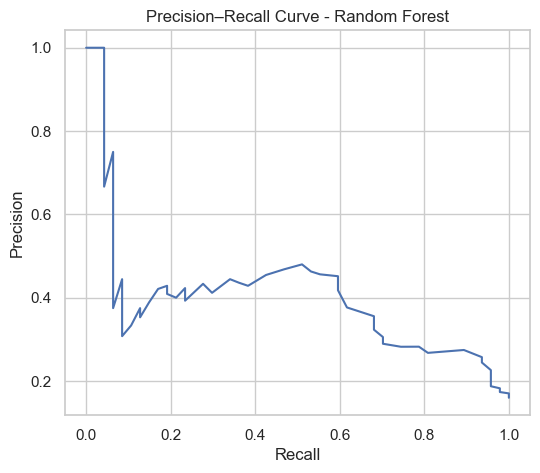

In [54]:
models_tree = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced'), # Giới hạn depth để tránh Overfitting
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
}

sns.set(style="whitegrid")

for name, model in models_tree.items():
    
    print(f"\n===== {name} =====")

    # Train
    model.fit(X_train_sc, y_train_sc)

    # Predict
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    # Accuracy + Report
    acc = accuracy_score(y_test_sc, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test_sc, y_pred))

    # --------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------
    cm = confusion_matrix(y_test_sc, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # --------------------------------------
    # PRECISION–RECALL CURVE
    # --------------------------------------
    precision, recall, _ = precision_recall_curve(y_test_sc, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision)
    plt.title(f"Precision–Recall Curve - {name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

**Nhận xét:**
+ **Decision Tree:** Mô hình Decision Tree đạt Accuracy 72.79% tương đương Logistic Regression, nhưng hiệu suất trên lớp thiểu số kém hơn đáng kể so với SVM khi Recall chỉ đạt 0.55 (tỷ lệ False Negative 45%), Precision 0.31 (trong 85 dự báo thì 59 là báo động giả) và F1-score lớp thiểu số chỉ 0.39 đạt mức thấp nhất trong các mô hình đã thử. Nhìn chung Decision Tree dễ bị overfitting và xử lý rất kém dữ liệu mất cân bằng.

+ **Random Forest:** Mô hình Random Forest đạt Accuracy 83.67%, cao nhất trong tất cả các mô hình đã thử đồng thời thể hiện hiệu suất vượt trội trên lớp thiểu số, mô hình gần như đạt hiệu suất tối ưu cho mục tiêu phát hiện sớm nhân viên có nguy cơ nghỉ việc và lượng False Negative ở mức rất thấp. Đây là mô hình nên được chọn để triển khai thực tế và làm cơ sở cho các bước tinh chỉnh tiếp theo.

### 2.3. So sánh giữa các mô hình

Đánh giá tổng quát các mô hình rồi dưa ra mô hình hoạt động tốt nhất nhằm tối ưu các tham số.

<Figure size 1000x600 with 0 Axes>

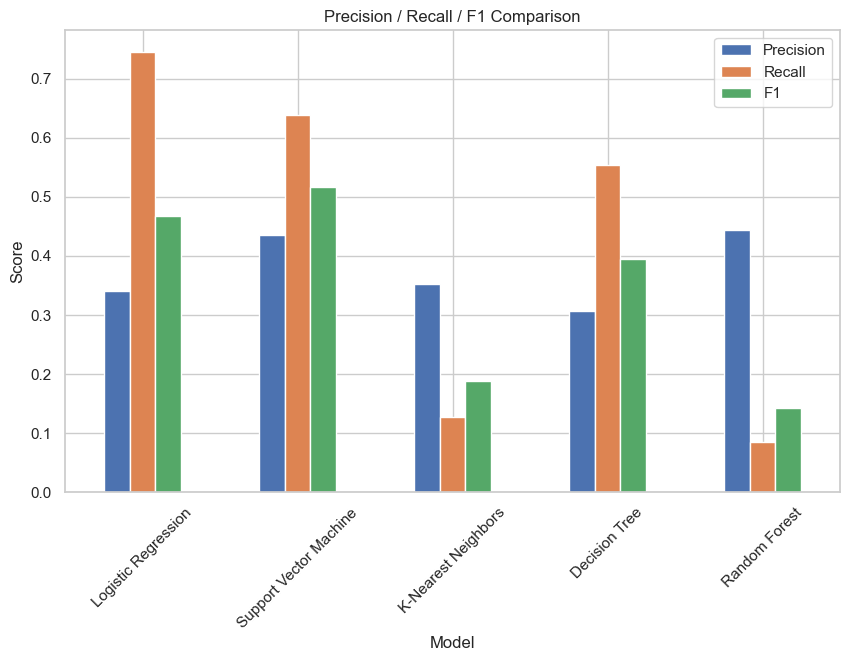

,Model,Precision,Recall,F1
0,Logistic Regression,0.339806,0.744681,0.466667
1,Support Vector Machine,0.434783,0.638298,0.517241
2,K-Nearest Neighbors,0.352941,0.127660,0.187500
3,Decision Tree,0.305882,0.553191,0.393939
4,Random Forest,0.444444,0.085106,0.142857


In [55]:
all_models = {}
all_models.update(models_sc)
all_models.update(models_tree)

metrics_list = []

for name, model in all_models.items():
    model.fit(X_train_sc, y_train_sc)
    y_pred = model.predict(X_test_sc)

    precision = precision_score(y_test_sc, y_pred)
    recall = recall_score(y_test_sc, y_pred)
    f1 = f1_score(y_test_sc, y_pred)

    metrics_list.append([name, precision, recall, f1])

df_metrics = pd.DataFrame(metrics_list, columns=["Model", "Precision", "Recall", "F1"])

plt.figure(figsize=(10,6))
df_metrics.plot(x="Model", kind="bar", figsize=(10,6))
plt.title("Precision / Recall / F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

df_metrics


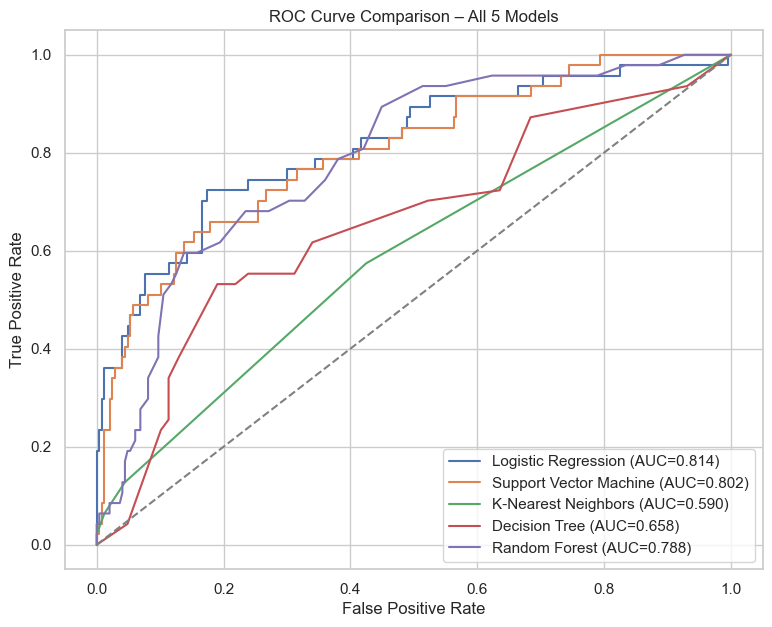

In [56]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9,7))

for name, model in all_models.items():

    model.fit(X_train_sc, y_train_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_sc, y_prob)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

# baseline
plt.plot([0,1], [0,1], '--', color='gray')

plt.title("ROC Curve Comparison – All 5 Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()


**Nhận xét:** Có thể thấy mô hình SVM hoạt động tốt nhất nhưng bộ dữ liệu quan tâm đến độ nhạy (Recall) hơn là sự cân bằng nên Random Forest vẫn là lựa chọn ưu tiên hơn.

## 3. Mô hình tối ưu Random Forest

Sau khi có được mô hình, ta bắt đầu việc tối ưu hóa bằng cách sử dụng GridSearch. 

### 3.1. Đánh giá mô hình Random Forest sau khi sử dụng GridSearch

Load mô hình đã lưu ở file Model.ipynb

In [57]:
# 1. Load mô hình
loaded_model = joblib.load('best_random_forest_model.pkl')

print("Đã load mô hình thành công!")
print(loaded_model)
best_params = loaded_model.get_params()

print("Các tham số tối ưu từ GridSearch trước đó:")
print(f"  - Max Depth: {best_params.get('max_depth')}")
print(f"  - N Estimators: {best_params.get('n_estimators')}")
print(f"  - Min Samples Leaf: {best_params.get('min_samples_leaf')}")
print(f"  - Class Weight: {best_params.get('class_weight')}")



Đã load mô hình thành công!
RandomForestClassifier(class_weight='balanced', max_depth=3,
                       min_samples_leaf=30, random_state=42)
Các tham số tối ưu từ GridSearch trước đó:
  - Max Depth: 3
  - N Estimators: 100
  - Min Samples Leaf: 30
  - Class Weight: balanced


**Nhận xét:** Đây là mô hình Random Forest tối ưu nhất cho bộ dữ liệu này.

In [58]:
y_pred = loaded_model.predict(X_test_raw)
y_prob = loaded_model.predict_proba(X_test_raw)[:, 1]

In [ ]:
acc = accuracy_score(y_test_raw, y_pred)
print(f"\nAccuracy = {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_raw, y_pred))


Accuracy = 0.7959

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.84      0.87       247
         1.0       0.40      0.57      0.47        47

    accuracy                           0.80       294
   macro avg       0.66      0.71      0.67       294
weighted avg       0.83      0.80      0.81       294



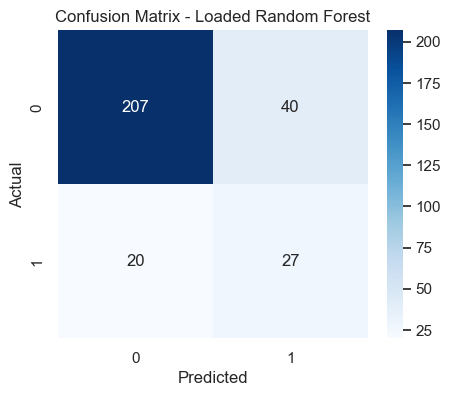

In [ ]:
#Confusion matrix
cm = confusion_matrix(y_test_raw, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Loaded Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

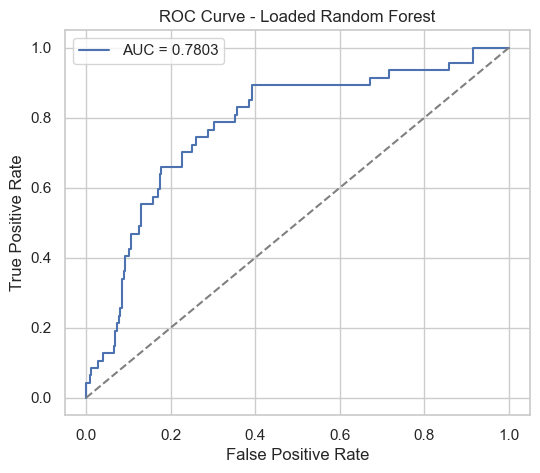

In [ ]:
# ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test_raw, y_prob)
auc_score = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.title("ROC Curve - Loaded Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


**Nhận xét:** Mô hình Random Forest sau khi tinh chỉnh bằng GridSearch có khả năng phân loại tốt với nhóm nhân viên ở lại (lớp 0) nhưng vẫn gặp khó khăn đáng kể với nhóm nhân viên nghỉ việc (lớp 1) do mất cân bằng dữ liệu. Mặc dù Recall của lớp 1 (0.57) đã cải thiện so với một số mô hình cơ bản (RF mặc định có Recall lớp 1 rất thấp) tuy nhiên Precision thấp (0.40) cho thấy sự đánh đổi để tìm được nhiều người nghỉ việc hơn, mô hình chấp nhận rủi ro dự đoán sai nhiều hơn.

**Kết luận:** Có thể thấy vấn đề lớn nhất của bộ dữ liệu là sự mất cân bằng. Để mô hình chạy tối ưu nhất, ta sẽ thử sử dụng SMOTE nhằm giải quyết vấn đề này.

### 3.2. Xử lí mất cân bằng dữ liệu

In [62]:
# Áp dụng SMOTE lên tập train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train_raw)

print(f"Kích thước Train gốc: {X_train_raw.shape}")
print(f"Kích thước Train sau SMOTE: {X_train_smote.shape}")

# HUẤN LUYỆN LẠI MODEL (PARAMS CŨ + DỮ LIỆU MỚI)
# Khởi tạo model mới nhưng dùng tham số tốt nhất cũ (**best_params)
rf_smote_final = RandomForestClassifier(**best_params)
rf_smote_final.fit(X_train_smote, y_train_smote)

Kích thước Train gốc: (1176, 25)
Kích thước Train sau SMOTE: (1972, 25)


,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 3.3. Tìm ngưỡng tối ưu

Trước khi chạy dữ liệu với SMOTE, chúng ta sẽ tìm thêm tham số tối ưu để trả lời cho vấn đề báo cáo đặt ra:

*+ Thay vì sử dụng ngưỡng mặc định 0.5, đâu là 'ngưỡng quyết định' (Decision 
Threshold) tối ưu để cân bằng giữa Precision và Recall, nhằm tối đa hóa lợi ích quản trị 
dựa trên ma trận chi phí giả định?*

In [63]:
# Threshold tuning (tìm ngưỡng tối ưu)
y_prob_test = rf_smote_final.predict_proba(X_test_raw)[:, 1]

# Chạy vòng lặp tìm ngưỡng cho F1 cao nhất
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test_raw, y_prob_test >= t) for t in thresholds]

# Lấy ngưỡng tốt nhất
best_ix = np.argmax(f1_scores)
best_thresh = thresholds[best_ix]
best_f1 = f1_scores[best_ix]

print(f"\n=== Kết quả tối ưu: GridSearch + SMOTE + Threshold tuning ===")
print(f" Ngưỡng tối ưu (Best Threshold): {best_thresh:.3f}")
print(f" F1-Score tại ngưỡng này: {best_f1:.4f}")



=== Kết quả tối ưu: GridSearch + SMOTE + Threshold tuning ===
 Ngưỡng tối ưu (Best Threshold): 0.450
 F1-Score tại ngưỡng này: 0.5645


## 4. Đánh giá


Báo cáo phân loại (Final Optimized Model):
              precision    recall  f1-score   support

         0.0       0.94      0.83      0.88       247
         1.0       0.45      0.74      0.56        47

    accuracy                           0.82       294
   macro avg       0.70      0.79      0.72       294
weighted avg       0.87      0.82      0.83       294



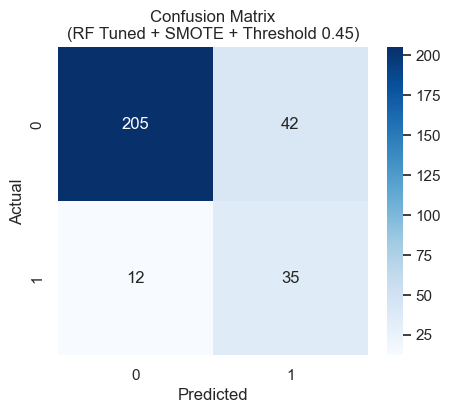

In [64]:
# Tạo dự đoán cuối cùng dựa trên ngưỡng mới
y_pred_final = (y_prob_test >= best_thresh).astype(int)

print("\nBáo cáo phân loại (Final Optimized Model):")
print(classification_report(y_test_raw, y_pred_final))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test_raw, y_pred_final)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix\n(RF Tuned + SMOTE + Threshold {best_thresh:.2f})")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



**Nhận xét:** 
+ Việc áp dụng các kỹ thuật can thiệp như SMOTE đã giúp F1-score cũng như Recall của lớp 01 (thiểu số) tăng lên đáng kể.
+ Thay vì sử dụng ngưỡng mặc định 0.5, sau tối ưu Precision và Recall cân bằng hơn, ma trận nhầm lẫn cũng nhận diện các giá trị tốt hơn. 
+ Nhìn chung, mô hình đã có sự cân bằng dữ liệu hơn.